In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from stable_baselines3 import DQN, A2C

import tqdm
import rich

import gymnasium as gym
from gymnasium import spaces

import importlib
import environment

importlib.reload(environment)

from environment import TradingEnv

In [2]:
COMPANY = "Infosys"
TICKER = "INFY.NS"

DATA_PATH = "data/infosys/INFY.csv"
MODEL_PATH = "models/infosys"

INITIAL_CAPITAL = 100_000

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42

Load Data

In [3]:
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(f"Company: {COMPANY}")
print(f"Ticker: {TICKER}")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

df.head()

Company: Infosys
Ticker: INFY.NS
Rows: 4,131
Date range: 2010-01-04 → 2026-09-21


,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,217.472549,326.575012,328.750000,324.412506,326.250000,4069264
1,2010-01-05,218.200928,327.668762,328.837494,325.012512,327.500000,6895528
2,2010-01-06,215.017029,322.887512,335.375000,321.887512,335.375000,6817288
3,2010-01-07,210.184906,315.631256,323.325012,314.774994,323.325012,10892600
4,2010-01-08,205.119812,308.024994,315.412506,307.250000,314.875000,12649312


Calculate Features

In [4]:
df["Return"] = df["Close"].pct_change()

df["Volume_Change"] = df["Volume"].pct_change()

df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["Volatility_20"] = df["Return"].rolling(window=20).std()

df["Close_SMA20"] = df["Close"] / df["SMA_20"] - 1
df["Close_SMA50"] = df["Close"] / df["SMA_50"] - 1
df["EMA_Ratio"] = df["EMA_12"] / df["EMA_26"] - 1

In [5]:
FEATURES = [
    "Return",
    "Volume_Change",
    "Close_SMA20",
    "Close_SMA50",
    "EMA_Ratio",
    "Volatility_20",
]

In [6]:
print("Infinite values:")
print(np.isinf(df[FEATURES]).sum())

print("\nNaN values:")
print(df[FEATURES].isna().sum())

Infinite values:
Return           0
Volume_Change    8
Close_SMA20      0
Close_SMA50      0
EMA_Ratio        0
Volatility_20    0
dtype: int64

NaN values:
Return            1
Volume_Change     1
Close_SMA20      19
Close_SMA50      49
EMA_Ratio         0
Volatility_20    20
dtype: int64


In [7]:
df[FEATURES] = df[FEATURES].replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(
    subset=FEATURES
).reset_index(drop=True)

print("Rows after feature engineering:", len(df))

Rows after feature engineering: 4074


Train, Validation, Test Split

In [8]:
n = len(df)

train_end = int(n * TRAIN_RATIO)

validation_end = int(
    n * (TRAIN_RATIO + VALIDATION_RATIO)
)

train_df = df.iloc[:train_end].copy()

validation_df = df.iloc[
    train_end:validation_end
].copy()

test_df = df.iloc[
    validation_end:
].copy()

print("TRAIN")
print(train_df["Date"].min(), "→", train_df["Date"].max())
print(f"Rows: {len(train_df):,}")

print("\nVALIDATION")
print(validation_df["Date"].min(), "→", validation_df["Date"].max())
print(f"Rows: {len(validation_df):,}")

print("\nTEST")
print(test_df["Date"].min(), "→", test_df["Date"].max())
print(f"Rows: {len(test_df):,}")

TRAIN
2010-03-17 00:00:00 → 2021-10-06 00:00:00
Rows: 2,851

VALIDATION
2021-10-07 00:00:00 → 2024-03-27 00:00:00
Rows: 611

TEST
2024-03-28 00:00:00 → 2026-09-21 00:00:00
Rows: 612


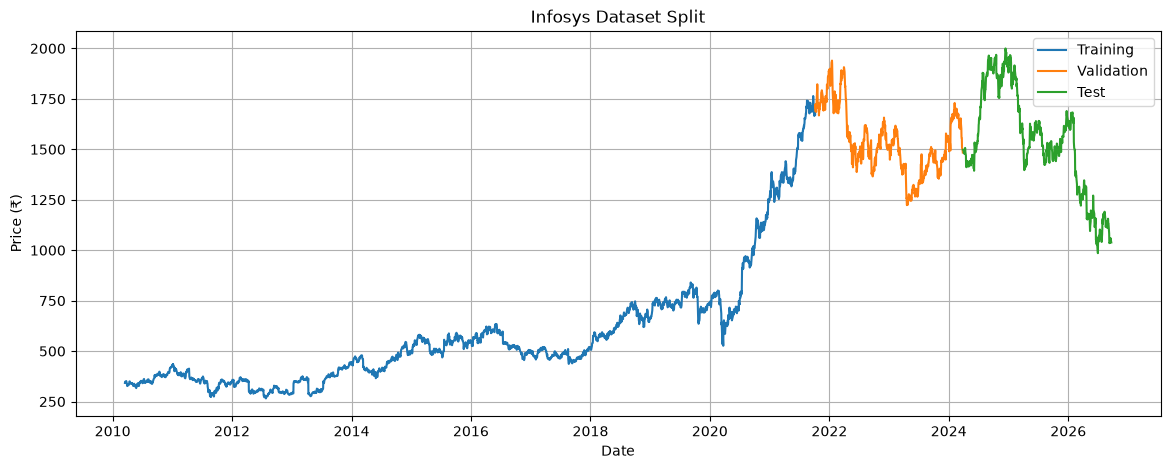

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_df["Date"],
    train_df["Close"],
    label="Training"
)

plt.plot(
    validation_df["Date"],
    validation_df["Close"],
    label="Validation"
)

plt.plot(
    test_df["Date"],
    test_df["Close"],
    label="Test"
)

plt.title(f"{COMPANY} Dataset Split")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.show()

Feature Scaling

In [10]:
scaler = StandardScaler()

train_features = scaler.fit_transform(
    train_df[FEATURES]
)

validation_features = scaler.transform(
    validation_df[FEATURES]
)

test_features = scaler.transform(
    test_df[FEATURES]
)

train_scaled = train_df.copy()
validation_scaled = validation_df.copy()
test_scaled = test_df.copy()

train_scaled[FEATURES] = train_features
validation_scaled[FEATURES] = validation_features
test_scaled[FEATURES] = test_features

Create Datasets

In [11]:
X_train = train_scaled[FEATURES].copy()
X_validation = validation_scaled[FEATURES].copy()
X_test = test_scaled[FEATURES].copy()

Y_train = train_df["Close"].copy()
Y_validation = validation_df["Close"].copy()
Y_test = test_df["Close"].copy()

X_train.index = train_df["Date"]
X_validation.index = validation_df["Date"]
X_test.index = test_df["Date"]

Y_train.index = train_df["Date"]
Y_validation.index = validation_df["Date"]
Y_test.index = test_df["Date"]

In [12]:
print("Feature columns:")
print(FEATURES)

print("\nX_train:")
print(X_train.shape)

print("\nY_train:")
print(Y_train.shape)

print("\nX_validation:")
print(X_validation.shape)

print("\nY_validation:")
print(Y_validation.shape)

print("\nX_test:")
print(X_test.shape)

print("\nY_test:")
print(Y_test.shape)

Feature columns:
['Return', 'Volume_Change', 'Close_SMA20', 'Close_SMA50', 'EMA_Ratio', 'Volatility_20']

X_train:
(2851, 6)

Y_train:
(2851,)

X_validation:
(611, 6)

Y_validation:
(611,)

X_test:
(612, 6)

Y_test:
(612,)


In [13]:
display(X_train.head())
display(Y_train.head())

,Return,Volume_Change,Close_SMA20,Close_SMA50,EMA_Ratio,Volatility_20
Date,,,,,,
2010-03-17,0.083029,-0.084962,0.839241,0.738564,0.767167,-0.953085
2010-03-18,0.983438,0.277623,1.161150,1.011284,0.879272,-0.951659
2010-03-19,-0.352105,0.283602,0.908552,0.900635,0.928742,-0.910661
2010-03-22,-0.347664,-0.926281,0.667319,0.789068,0.929700,-0.883217
2010-03-23,0.332597,0.011581,0.733905,0.865068,0.946068,-0.919660


Date
2010-03-17    342.287506
2010-03-18    348.450012
2010-03-19    346.543762
2010-03-22    344.674988
2010-03-23    346.937500
Name: Close, dtype: float64

Create Environments

In [14]:
train_env = TradingEnv(
    features=X_train,
    prices=Y_train,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost=0.001,
)

validation_env = TradingEnv(
    features=X_validation,
    prices=Y_validation,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost=0.001,
)

test_env = TradingEnv(
    features=X_test,
    prices=Y_test,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost=0.001,
)

DQN

In [15]:
DQN_TIMESTEPS = 50_000

DQN_LEARNING_RATE = 1e-4
DQN_BUFFER_SIZE = 10_000
DQN_LEARNING_STARTS = 1_000
DQN_BATCH_SIZE = 64
DQN_GAMMA = 0.99
DQN_TRAIN_FREQ = 4
DQN_TARGET_UPDATE_INTERVAL = 1_000

DQN_EXPLORATION_FRACTION = 0.20
DQN_EXPLORATION_FINAL_EPS = 0.05

In [16]:
dqn_model = DQN(
    policy="MlpPolicy",
    env=train_env,

    learning_rate=DQN_LEARNING_RATE,
    buffer_size=DQN_BUFFER_SIZE,
    learning_starts=DQN_LEARNING_STARTS,
    batch_size=DQN_BATCH_SIZE,

    gamma=DQN_GAMMA,
    train_freq=DQN_TRAIN_FREQ,
    target_update_interval=DQN_TARGET_UPDATE_INTERVAL,

    exploration_fraction=DQN_EXPLORATION_FRACTION,
    exploration_final_eps=DQN_EXPLORATION_FINAL_EPS,

    policy_kwargs=dict(
        net_arch=[128, 128]
    ),

    seed=RANDOM_SEED,
    verbose=1,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [17]:
dqn_model.learn(
    total_timesteps=DQN_TIMESTEPS,
    progress_bar=True,
)

Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 0.923    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1786     |
|    time_elapsed     | 6        |
|    total_timesteps  | 11400    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 9.91e-05 |
|    n_updates        | 2599     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 1.65     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1649     |
|    time_elapsed     | 13       |
|    total_timesteps  | 22800    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000168 |
|    n_updates        | 5449     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 2.12     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1617     |
|    time_elapsed     | 21       |
|    total_timesteps  | 34200    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.79e-05 |
|    n_updates        | 8299     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 2.47     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 16       |
|    fps              | 1594     |
|    time_elapsed     | 28       |
|    total_timesteps  | 45600    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000153 |
|    n_updates        | 11149    |
----------------------------------


In [18]:
MODEL_DIR = Path(MODEL_PATH)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

dqn_model.save(
    MODEL_DIR / "dqn_infosys"
)

print(f"DQN model saved to: {MODEL_DIR / 'dqn_infosys'}")

DQN model saved to: models/infosys/dqn_infosys


A2C

In [19]:
A2C_TIMESTEPS = 50_000

A2C_LEARNING_RATE = 3e-4
A2C_GAMMA = 0.99
A2C_N_STEPS = 5
A2C_ENT_COEF = 0.0
A2C_VF_COEF = 0.5

In [20]:
a2c_model = A2C(
    policy="MlpPolicy",
    env=train_env,

    learning_rate=A2C_LEARNING_RATE,
    gamma=A2C_GAMMA,
    n_steps=A2C_N_STEPS,

    ent_coef=A2C_ENT_COEF,
    vf_coef=A2C_VF_COEF,

    policy_kwargs=dict(
        net_arch=[128, 128]
    ),

    seed=RANDOM_SEED,
    verbose=1,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [21]:
a2c_model.learn(
    total_timesteps=A2C_TIMESTEPS,
    progress_bar=True,
)

Output()

------------------------------------
| time/                 |          |
|    fps                | 1033     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -1.1     |
|    explained_variance | -286     |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | -0.0245  |
|    value_loss         | 0.000764 |
------------------------------------


------------------------------------
| time/                 |          |
|    fps                | 1015     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -1.08    |
|    explained_variance | -28.5    |
|    learning_rate      | 0.0003   |
|    n_updates          | 199      |
|    policy_loss        | 0.0861   |
|    value_loss         | 0.0132   |
------------------------------------


------------------------------------
| time/                 |          |
|    fps                | 1034     |
|    iterations         | 300      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1500     |
| train/                |          |
|    entropy_loss       | -1.09    |
|    explained_variance | 0.844    |
|    learning_rate      | 0.0003   |
|    n_updates          | 299      |
|    policy_loss        | -0.0038  |
|    value_loss         | 3.38e-05 |
------------------------------------


------------------------------------
| time/                 |          |
|    fps                | 1051     |
|    iterations         | 400      |
|    time_elapsed       | 1        |
|    total_timesteps    | 2000     |
| train/                |          |
|    entropy_loss       | -1.07    |
|    explained_variance | -2.18    |
|    learning_rate      | 0.0003   |
|    n_updates          | 399      |
|    policy_loss        | -0.0263  |
|    value_loss         | 0.00172  |
------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 0.989    |
| time/                 |          |
|    fps                | 989      |
|    iterations         | 9600     |
|    time_elapsed       | 48       |
|    total_timesteps    | 48000    |
| train/                |          |
|    entropy_loss       | -0.78    |
|    explained_variance | -6.53    |
|    learning_rate      | 0.0003   |
|    n_updates          | 9599     |
|    policy_loss        | -0.00684 |
|    value_loss         | 8.66e-05 |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1        |
| time/                 |          |
|    fps                | 989      |
|    iterations         | 9700     |
|    time_elapsed       | 49       |
|    total_timesteps    | 48500    |
| train/                |          |
|    entropy_loss       | -0.0808  |
|    explained_variance | -1.3     |
|    learning_rate      | 0.0003   |
|    n_updates          | 9699     |
|    policy_loss        | 3.05e-05 |
|    value_loss         | 0.000126 |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1        |
| time/                 |          |
|    fps                | 989      |
|    iterations         | 9800     |
|    time_elapsed       | 49       |
|    total_timesteps    | 49000    |
| train/                |          |
|    entropy_loss       | -0.0736  |
|    explained_variance | -144     |
|    learning_rate      | 0.0003   |
|    n_updates          | 9799     |
|    policy_loss        | 0.000125 |
|    value_loss         | 3.89e-05 |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1        |
| time/                 |          |
|    fps                | 989      |
|    iterations         | 9900     |
|    time_elapsed       | 50       |
|    total_timesteps    | 49500    |
| train/                |          |
|    entropy_loss       | -0.153   |
|    explained_variance | -482     |
|    learning_rate      | 0.0003   |
|    n_updates          | 9899     |
|    policy_loss        | -0.00163 |
|    value_loss         | 0.000645 |
------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 2.85e+03  |
|    ep_rew_mean        | 1         |
| time/                 |           |
|    fps                | 990       |
|    iterations         | 10000     |
|    time_elapsed       | 50        |
|    total_timesteps    | 50000     |
| train/                |           |
|    entropy_loss       | -0.0257   |
|    explained_variance | 0.852     |
|    learning_rate      | 0.0003    |
|    n_updates          | 9999      |
|    policy_loss        | -6.13e-07 |
|    value_loss         | 1.62e-05  |
-------------------------------------


In [22]:
MODEL_DIR = Path(MODEL_PATH)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

a2c_model.save(
    MODEL_DIR / "a2c_infosys"
)

print(f"A2C model saved to: {MODEL_DIR / 'a2c_infosys'}")

A2C model saved to: models/infosys/a2c_infosys


Baseline Validation Metrics

In [23]:
def evaluate_buy_and_hold(
    prices,
    initial_capital=100_000,
):
    prices = pd.Series(prices)

    # Buy at the first available price
    initial_price = float(prices.iloc[0])

    # Number of shares purchased
    shares = initial_capital / initial_price

    # Portfolio value throughout the period
    portfolio_values = (
        shares * prices.to_numpy(dtype=float)
    )

    dates = list(prices.index)

    # Buy & Hold has one initial trade
    actions = [1] + [0] * (len(prices) - 1)

    final_portfolio = float(portfolio_values[-1])

    total_return = (
        final_portfolio / initial_capital
    ) - 1

    return {
        "portfolio_values": portfolio_values,
        "dates": dates,
        "actions": actions,
        "initial_capital": initial_capital,
        "final_portfolio": final_portfolio,
        "total_return": total_return,
        "trade_count": 1,
    }

In [24]:
def evaluate_model(model, features, prices, initial_capital=100_000, transaction_cost=0.001):
    env = TradingEnv(
        features=features,
        prices=prices,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
    )

    obs, info = env.reset()

    portfolio_values = [initial_capital]
    dates = [info["date"]]
    actions = []

    terminated = False
    truncated = False

    while not (terminated or truncated):

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(int(action))
        portfolio_values.append(info["portfolio_value"])
        dates.append(info["date"])

    return {
        "env": env,
        "portfolio_values": np.array(portfolio_values),
        "dates": dates,
        "actions": actions,
    }

In [25]:
dqn_eval = evaluate_model(
    dqn_model,
    X_validation,
    Y_validation,
    INITIAL_CAPITAL,
    0.001,
)

a2c_eval = evaluate_model(
    a2c_model,
    X_validation,
    Y_validation,
    INITIAL_CAPITAL,
    0.001,
)

buy_hold_eval = evaluate_buy_and_hold(
    prices=Y_validation,
    initial_capital=INITIAL_CAPITAL,
)

In [26]:
print(
    f"Final portfolio: "
    f"₹{buy_hold_eval['final_portfolio']:,.2f}"
)

print(
    f"Total return: "
    f"{buy_hold_eval['total_return']:.2%}"
)

print(
    f"Trades: "
    f"{buy_hold_eval['trade_count']}"
)

Final portfolio: ₹87,749.85
Total return: -12.25%
Trades: 1


In [27]:
def calculate_metrics(
    portfolio_values,
    initial_capital=100_000,
):
    """
    Calculate portfolio performance metrics.

    Assumptions:
    - Daily observations
    - 252 trading days/year
    - Risk-free rate = 0
    """

    portfolio_values = np.asarray(
        portfolio_values,
        dtype=np.float64
    )

    # Daily portfolio returns
    daily_returns = (
        portfolio_values[1:] / portfolio_values[:-1]
    ) - 1

    # Total return
    total_return = (
        portfolio_values[-1] / initial_capital
    ) - 1

    # Running peak
    running_max = np.maximum.accumulate(
        portfolio_values
    )

    # Drawdown
    drawdowns = (
        portfolio_values / running_max
    ) - 1

    max_drawdown = drawdowns.min()

    # Sharpe ratio
    if daily_returns.std(ddof=1) == 0:
        sharpe_ratio = 0.0
    else:
        sharpe_ratio = (
            daily_returns.mean()
            / daily_returns.std(ddof=1)
        ) * np.sqrt(252)

    return {
        "Initial Capital": initial_capital,
        "Final Portfolio": float(portfolio_values[-1]),
        "Total Return": float(total_return),
        "Max Drawdown": float(max_drawdown),
        "Sharpe Ratio": float(sharpe_ratio),
    }

In [28]:
dqn_metrics = calculate_metrics(
    dqn_eval["portfolio_values"],
    INITIAL_CAPITAL,
)

dqn_metrics["Strategy"] = "DQN"
dqn_metrics["Trades"] = dqn_eval["env"].trade_count

dqn_metrics

{'Initial Capital': 100000,
 'Final Portfolio': 77628.51145913666,
 'Total Return': -0.22371488540863338,
 'Max Drawdown': -0.4354578588372968,
 'Sharpe Ratio': -0.3782083443032684,
 'Strategy': 'DQN',
 'Trades': 141}

In [29]:
a2c_metrics = calculate_metrics(
    a2c_eval["portfolio_values"],
    INITIAL_CAPITAL,
)

a2c_metrics["Strategy"] = "A2C"
a2c_metrics["Trades"] = a2c_eval["env"].trade_count

a2c_metrics

{'Initial Capital': 100000,
 'Final Portfolio': 87087.00077326468,
 'Total Return': -0.12912999226735322,
 'Max Drawdown': -0.3617810166386142,
 'Sharpe Ratio': -0.13480240111991446,
 'Strategy': 'A2C',
 'Trades': 13}

In [30]:
buy_hold_metrics = calculate_metrics(
    buy_hold_eval["portfolio_values"],
    INITIAL_CAPITAL,
)

buy_hold_metrics["Strategy"] = "Buy & Hold"
buy_hold_metrics["Trades"] = buy_hold_eval["trade_count"]

buy_hold_metrics

{'Initial Capital': 100000,
 'Final Portfolio': 87749.85071472131,
 'Total Return': -0.12250149285278689,
 'Max Drawdown': -0.3692188582551883,
 'Sharpe Ratio': -0.0838127421526337,
 'Strategy': 'Buy & Hold',
 'Trades': 1}

In [31]:
validation_metrics = pd.DataFrame([
    dqn_metrics,
    a2c_metrics,
    buy_hold_metrics,
])

validation_metrics = validation_metrics[
    [
        "Strategy",
        "Initial Capital",
        "Final Portfolio",
        "Total Return",
        "Max Drawdown",
        "Sharpe Ratio",
        "Trades",
    ]
]

validation_metrics

,Strategy,Initial Capital,Final Portfolio,Total Return,Max Drawdown,Sharpe Ratio,Trades
0,DQN,100000,77628.511459,-0.223715,-0.435458,-0.378208,141
1,A2C,100000,87087.000773,-0.129130,-0.361781,-0.134802,13
2,Buy & Hold,100000,87749.850715,-0.122501,-0.369219,-0.083813,1


In [32]:
display_table = validation_metrics.copy()

display_table["Initial Capital"] = (
    display_table["Initial Capital"]
    .map(lambda x: f"₹{x:,.2f}")
)

display_table["Final Portfolio"] = (
    display_table["Final Portfolio"]
    .map(lambda x: f"₹{x:,.2f}")
)

display_table["Total Return"] = (
    display_table["Total Return"]
    .map(lambda x: f"{x:.2%}")
)

display_table["Max Drawdown"] = (
    display_table["Max Drawdown"]
    .map(lambda x: f"{x:.2%}")
)

display_table["Sharpe Ratio"] = (
    display_table["Sharpe Ratio"]
    .map(lambda x: f"{x:.3f}")
)

display_table

,Strategy,Initial Capital,Final Portfolio,Total Return,Max Drawdown,Sharpe Ratio,Trades
0,DQN,"₹100,000.00","₹77,628.51",-22.37%,-43.55%,-0.378,141
1,A2C,"₹100,000.00","₹87,087.00",-12.91%,-36.18%,-0.135,13
2,Buy & Hold,"₹100,000.00","₹87,749.85",-12.25%,-36.92%,-0.084,1


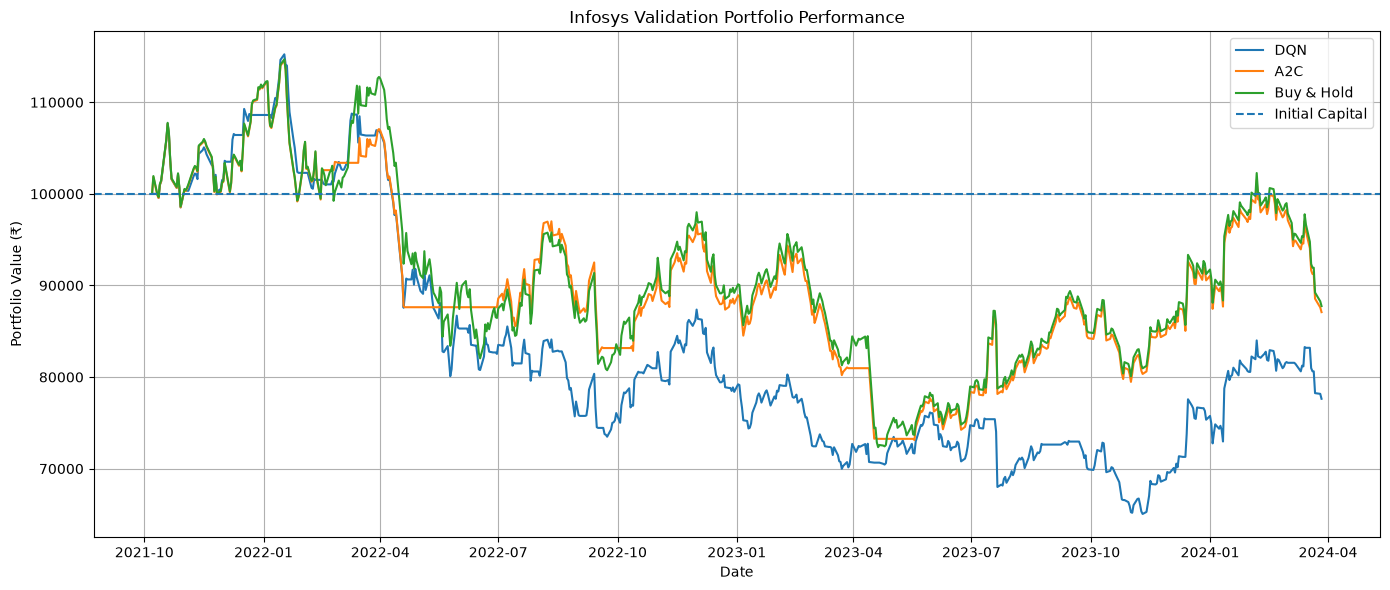

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    dqn_eval["dates"],
    dqn_eval["portfolio_values"],
    label="DQN",
)

plt.plot(
    a2c_eval["dates"],
    a2c_eval["portfolio_values"],
    label="A2C",
)

plt.plot(
    buy_hold_eval["dates"],
    buy_hold_eval["portfolio_values"],
    label="Buy & Hold",
)

plt.axhline(
    INITIAL_CAPITAL,
    linestyle="--",
    label="Initial Capital",
)

plt.title(f"{COMPANY} Validation Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

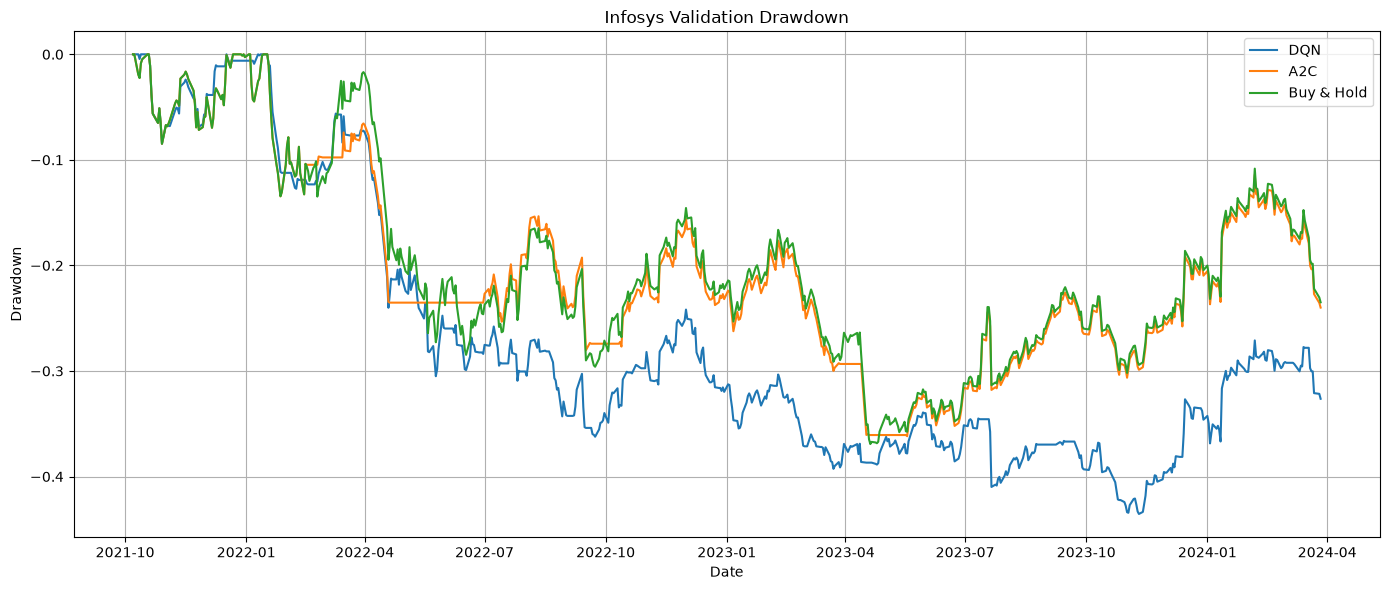

In [34]:
def calculate_drawdown(portfolio_values):
    portfolio_values = np.asarray(
        portfolio_values,
        dtype=np.float64
    )

    running_max = np.maximum.accumulate(
        portfolio_values
    )

    return (
        portfolio_values / running_max
    ) - 1

dqn_drawdown = calculate_drawdown(
    dqn_eval["portfolio_values"]
)

a2c_drawdown = calculate_drawdown(
    a2c_eval["portfolio_values"]
)

buy_hold_drawdown = calculate_drawdown(
    buy_hold_eval["portfolio_values"]
)

plt.figure(figsize=(14, 6))

plt.plot(
    dqn_eval["dates"],
    dqn_drawdown,
    label="DQN",
)

plt.plot(
    a2c_eval["dates"],
    a2c_drawdown,
    label="A2C",
)

plt.plot(
    buy_hold_eval["dates"],
    buy_hold_drawdown,
    label="Buy & Hold",
)

plt.title(f"{COMPANY} Validation Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Hyperparameter Tuning DQN

In [35]:
DQN_CONFIGS = [
    {
        "name": "DQN_1",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "batch_size": 64,
        "buffer_size": 10_000,
        "learning_starts": 1_000,
        "target_update_interval": 1_000,
        "exploration_fraction": 0.20,
        "exploration_final_eps": 0.05,
        "net_arch": [128, 128],
    },
    {
        "name": "DQN_2",
        "learning_rate": 5e-5,
        "gamma": 0.99,
        "batch_size": 64,
        "buffer_size": 20_000,
        "learning_starts": 1_000,
        "target_update_interval": 1_000,
        "exploration_fraction": 0.30,
        "exploration_final_eps": 0.05,
        "net_arch": [128, 128],
    },
    {
        "name": "DQN_3",
        "learning_rate": 1e-4,
        "gamma": 0.995,
        "batch_size": 64,
        "buffer_size": 20_000,
        "learning_starts": 1_000,
        "target_update_interval": 2_000,
        "exploration_fraction": 0.20,
        "exploration_final_eps": 0.05,
        "net_arch": [128, 128],
    },
    {
        "name": "DQN_4",
        "learning_rate": 5e-5,
        "gamma": 0.995,
        "batch_size": 128,
        "buffer_size": 20_000,
        "learning_starts": 1_000,
        "target_update_interval": 2_000,
        "exploration_fraction": 0.30,
        "exploration_final_eps": 0.05,
        "net_arch": [256, 128],
    },
]

In [36]:
dqn_tuning_results = []

for config in DQN_CONFIGS:

    print("=" * 60)
    print(f"Training {config['name']}")
    print("=" * 60)

    env = TradingEnv(
        features=X_train,
        prices=Y_train,
        initial_capital=INITIAL_CAPITAL,
        transaction_cost=0.001,
    )

    model = DQN(
        "MlpPolicy",
        env,

        learning_rate=config["learning_rate"],
        buffer_size=config["buffer_size"],
        learning_starts=config["learning_starts"],
        batch_size=config["batch_size"],

        gamma=config["gamma"],
        train_freq=4,
        target_update_interval=config["target_update_interval"],

        exploration_fraction=config["exploration_fraction"],
        exploration_final_eps=config["exploration_final_eps"],

        policy_kwargs={
            "net_arch": config["net_arch"]
        },

        seed=RANDOM_SEED,
        verbose=0,
    )

    model.learn(
        total_timesteps=50_000,
        progress_bar=True,
    )

    # Validation
    eval_result = evaluate_model(
        model,
        X_validation,
        Y_validation,
        INITIAL_CAPITAL,
        0.001,
    )

    metrics = calculate_metrics(
        eval_result["portfolio_values"],
        INITIAL_CAPITAL,
    )

    metrics["Configuration"] = config["name"]
    metrics["Trades"] = eval_result["env"].trade_count

    dqn_tuning_results.append(metrics)

    print(
        f"Validation return: "
        f"{metrics['Total Return']:.2%}"
    )

    print(
        f"Final portfolio: "
        f"₹{metrics['Final Portfolio']:,.2f}"
    )

    print(
        f"Trades: "
        f"{metrics['Trades']}"
    )

Output()

Training DQN_1


Output()

Validation return: -22.37%
Final portfolio: ₹77,628.51
Trades: 141
Training DQN_2


Output()

Validation return: -2.22%
Final portfolio: ₹97,784.53
Trades: 141
Training DQN_3


Output()

Validation return: -7.85%
Final portfolio: ₹92,146.65
Trades: 114
Training DQN_4


Validation return: -11.76%
Final portfolio: ₹88,243.34
Trades: 81


In [37]:
dqn_tuning_df = pd.DataFrame(dqn_tuning_results)

dqn_tuning_df = dqn_tuning_df[
    [
        "Configuration",
        "Initial Capital",
        "Final Portfolio",
        "Total Return",
        "Max Drawdown",
        "Sharpe Ratio",
        "Trades",
    ]
]

dqn_tuning_df

,Configuration,Initial Capital,Final Portfolio,Total Return,Max Drawdown,Sharpe Ratio,Trades
0,DQN_1,100000,77628.511459,-0.223715,-0.435458,-0.378208,141
1,DQN_2,100000,97784.529616,-0.022155,-0.376753,0.057008,141
2,DQN_3,100000,92146.645303,-0.078534,-0.341149,-0.070255,114
3,DQN_4,100000,88243.340680,-0.117567,-0.373704,-0.115814,81


In [38]:
dqn_tuning_df.sort_values(
    "Total Return",
    ascending=False
)

dqn_tuning_df.to_csv(
    "models/infosys/dqn_tuning_results.csv",
    index=False,
)

print("DQN tuning results saved.")

DQN tuning results saved.


Hyperparameter Tuning A2C

In [39]:
A2C_CONFIGS = [
    {
        "name": "A2C_1",
        "learning_rate": 3e-4,
        "gamma": 0.99,
        "n_steps": 5,
        "ent_coef": 0.0,
        "vf_coef": 0.5,
        "net_arch": [128, 128],
    },
    {
        "name": "A2C_2",
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "n_steps": 5,
        "ent_coef": 0.01,
        "vf_coef": 0.5,
        "net_arch": [128, 128],
    },
    {
        "name": "A2C_3",
        "learning_rate": 3e-4,
        "gamma": 0.995,
        "n_steps": 10,
        "ent_coef": 0.01,
        "vf_coef": 0.5,
        "net_arch": [128, 128],
    },
    {
        "name": "A2C_4",
        "learning_rate": 1e-4,
        "gamma": 0.995,
        "n_steps": 10,
        "ent_coef": 0.02,
        "vf_coef": 0.5,
        "net_arch": [256, 128],
    },
]

In [40]:
a2c_tuning_results = []

for config in A2C_CONFIGS:

    print("=" * 60)
    print(f"Training {config['name']}")
    print("=" * 60)

    env = TradingEnv(
        features=X_train,
        prices=Y_train,
        initial_capital=INITIAL_CAPITAL,
        transaction_cost=0.001,
    )

    model = A2C(
        "MlpPolicy",
        env,

        learning_rate=config["learning_rate"],
        gamma=config["gamma"],
        n_steps=config["n_steps"],

        ent_coef=config["ent_coef"],
        vf_coef=config["vf_coef"],

        policy_kwargs={
            "net_arch": config["net_arch"]
        },

        seed=RANDOM_SEED,
        verbose=0,
    )

    model.learn(
        total_timesteps=50_000,
        progress_bar=True,
    )

    # Validation
    eval_result = evaluate_model(
        model,
        X_validation,
        Y_validation,
        INITIAL_CAPITAL,
        0.001,
    )

    metrics = calculate_metrics(
        eval_result["portfolio_values"],
        INITIAL_CAPITAL,
    )

    metrics["Configuration"] = config["name"]
    metrics["Trades"] = eval_result["env"].trade_count

    a2c_tuning_results.append(metrics)

    print(
        f"Validation return: "
        f"{metrics['Total Return']:.2%}"
    )

    print(
        f"Final portfolio: "
        f"₹{metrics['Final Portfolio']:,.2f}"
    )

    print(
        f"Trades: "
        f"{metrics['Trades']}"
    )

Output()

Training A2C_1


Output()

Validation return: -12.91%
Final portfolio: ₹87,087.00
Trades: 13
Training A2C_2


Output()

Validation return: -13.60%
Final portfolio: ₹86,397.56
Trades: 1
Training A2C_3


Output()

Validation return: -19.35%
Final portfolio: ₹80,647.04
Trades: 13
Training A2C_4


Validation return: -14.36%
Final portfolio: ₹85,638.28
Trades: 42


In [41]:
a2c_tuning_df = pd.DataFrame(a2c_tuning_results)

a2c_tuning_df = a2c_tuning_df[
    [
        "Configuration",
        "Initial Capital",
        "Final Portfolio",
        "Total Return",
        "Max Drawdown",
        "Sharpe Ratio",
        "Trades",
    ]
]

a2c_tuning_df

,Configuration,Initial Capital,Final Portfolio,Total Return,Max Drawdown,Sharpe Ratio,Trades
0,A2C_1,100000,87087.000773,-0.129130,-0.361781,-0.134802,13
1,A2C_2,100000,86397.559412,-0.136024,-0.369219,-0.110211,1
2,A2C_3,100000,80647.041534,-0.193530,-0.360156,-0.288168,13
3,A2C_4,100000,85638.277533,-0.143617,-0.309811,-0.335924,42


In [51]:
a2c_tuning_df.to_csv(
    "models/infosys/a2c_tuning_results.csv",
    index=False,
)

print("A2C tuning results saved.")

A2C tuning results saved.


Train Best Models

In [43]:
BEST_DQN_CONFIG = {
    "name": "DQN_2",
    "learning_rate": 5e-5,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 20_000,
    "learning_starts": 1_000,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.30,
    "exploration_final_eps": 0.05,
    "net_arch": [128, 128],
}

BEST_A2C_CONFIG = {
    "name": "A2C_1",
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "n_steps": 5,
    "ent_coef": 0.0,
    "vf_coef": 0.5,
    "net_arch": [128, 128],
}

FINAL_TIMESTEPS = 100_000

final_dqn_env = TradingEnv(
    features=X_train,
    prices=Y_train,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost=0.001,
)

In [44]:
final_dqn_model = DQN(
    "MlpPolicy",
    final_dqn_env,

    learning_rate=BEST_DQN_CONFIG["learning_rate"],
    buffer_size=BEST_DQN_CONFIG["buffer_size"],
    learning_starts=BEST_DQN_CONFIG["learning_starts"],
    batch_size=BEST_DQN_CONFIG["batch_size"],

    gamma=BEST_DQN_CONFIG["gamma"],
    train_freq=4,
    target_update_interval=BEST_DQN_CONFIG["target_update_interval"],

    exploration_fraction=BEST_DQN_CONFIG["exploration_fraction"],
    exploration_final_eps=BEST_DQN_CONFIG["exploration_final_eps"],

    policy_kwargs={
        "net_arch": BEST_DQN_CONFIG["net_arch"]
    },

    seed=RANDOM_SEED,
    verbose=1,
)

final_dqn_model.learn(
    total_timesteps=FINAL_TIMESTEPS,
    progress_bar=True,
)

final_dqn_model.save(
    MODEL_DIR / "dqn_infosys_final"
)

print(
    f"Saved: {MODEL_DIR / 'dqn_infosys_final.zip'}"
)

Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 0.168    |
|    exploration_rate | 0.639    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1920     |
|    time_elapsed     | 5        |
|    total_timesteps  | 11400    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 0.000346 |
|    n_updates        | 2599     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 0.761    |
|    exploration_rate | 0.278    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1723     |
|    time_elapsed     | 13       |
|    total_timesteps  | 22800    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 8.95e-05 |
|    n_updates        | 5449     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 1.18     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1615     |
|    time_elapsed     | 21       |
|    total_timesteps  | 34200    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 8.68e-05 |
|    n_updates        | 8299     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 1.64     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 16       |
|    fps              | 1581     |
|    time_elapsed     | 28       |
|    total_timesteps  | 45600    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 9.84e-05 |
|    n_updates        | 11149    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 2.05     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 20       |
|    fps              | 1544     |
|    time_elapsed     | 36       |
|    total_timesteps  | 57000    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 4.19e-05 |
|    n_updates        | 13999    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 2.42     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 24       |
|    fps              | 1513     |
|    time_elapsed     | 45       |
|    total_timesteps  | 68400    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 3.93e-05 |
|    n_updates        | 16849    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.85e+03 |
|    ep_rew_mean      | 2.72     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 28       |
|    fps              | 1462     |
|    time_elapsed     | 54       |
|    total_timesteps  | 79800    |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 3.02e-05 |
|    n_updates        | 19699    |
----------------------------------


Saved: models/infosys/dqn_infosys_final.zip


In [45]:
final_a2c_env = TradingEnv(
    features=X_train,
    prices=Y_train,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost=0.001,
)

In [46]:
final_a2c_model = A2C(
    "MlpPolicy",
    final_a2c_env,

    learning_rate=BEST_A2C_CONFIG["learning_rate"],
    gamma=BEST_A2C_CONFIG["gamma"],
    n_steps=BEST_A2C_CONFIG["n_steps"],

    ent_coef=BEST_A2C_CONFIG["ent_coef"],
    vf_coef=BEST_A2C_CONFIG["vf_coef"],

    policy_kwargs={
        "net_arch": BEST_A2C_CONFIG["net_arch"]
    },

    seed=RANDOM_SEED,
    verbose=1,
)

final_a2c_model.learn(
    total_timesteps=FINAL_TIMESTEPS,
    progress_bar=True,
)

final_a2c_model.save(
    MODEL_DIR / "a2c_infosys_final"
)

print(
    f"Saved: {MODEL_DIR / 'a2c_infosys_final.zip'}"
)

Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


------------------------------------
| time/                 |          |
|    fps                | 1006     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -1.1     |
|    explained_variance | -286     |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | -0.0245  |
|    value_loss         | 0.000764 |
------------------------------------


------------------------------------
| time/                 |          |
|    fps                | 988      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -1.08    |
|    explained_variance | -28.5    |
|    learning_rate      | 0.0003   |
|    n_updates          | 199      |
|    policy_loss        | 0.0861   |
|    value_loss         | 0.0132   |
------------------------------------


------------------------------------
| time/                 |          |
|    fps                | 988      |
|    iterations         | 300      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1500     |
| train/                |          |
|    entropy_loss       | -1.09    |
|    explained_variance | 0.844    |
|    learning_rate      | 0.0003   |
|    n_updates          | 299      |
|    policy_loss        | -0.0038  |
|    value_loss         | 3.38e-05 |
------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1.15     |
| time/                 |          |
|    fps                | 1011     |
|    iterations         | 19700    |
|    time_elapsed       | 97       |
|    total_timesteps    | 98500    |
| train/                |          |
|    entropy_loss       | -0.2     |
|    explained_variance | -1.4     |
|    learning_rate      | 0.0003   |
|    n_updates          | 19699    |
|    policy_loss        | 0.00107  |
|    value_loss         | 0.00068  |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1.15     |
| time/                 |          |
|    fps                | 1011     |
|    iterations         | 19800    |
|    time_elapsed       | 97       |
|    total_timesteps    | 99000    |
| train/                |          |
|    entropy_loss       | -0.435   |
|    explained_variance | 0.826    |
|    learning_rate      | 0.0003   |
|    n_updates          | 19799    |
|    policy_loss        | 0.00168  |
|    value_loss         | 2.94e-05 |
------------------------------------


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 2.85e+03  |
|    ep_rew_mean        | 1.15      |
| time/                 |           |
|    fps                | 1011      |
|    iterations         | 19900     |
|    time_elapsed       | 98        |
|    total_timesteps    | 99500     |
| train/                |           |
|    entropy_loss       | -0.453    |
|    explained_variance | -1.68     |
|    learning_rate      | 0.0003    |
|    n_updates          | 19899     |
|    policy_loss        | -0.000496 |
|    value_loss         | 0.000731  |
-------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2.85e+03 |
|    ep_rew_mean        | 1.16     |
| time/                 |          |
|    fps                | 1012     |
|    iterations         | 20000    |
|    time_elapsed       | 98       |
|    total_timesteps    | 100000   |
| train/                |          |
|    entropy_loss       | -0.213   |
|    explained_variance | -0.941   |
|    learning_rate      | 0.0003   |
|    n_updates          | 19999    |
|    policy_loss        | 0.015    |
|    value_loss         | 0.000495 |
------------------------------------


Saved: models/infosys/a2c_infosys_final.zip


Testing

In [47]:
final_dqn_test = evaluate_model(
    final_dqn_model,
    X_test,
    Y_test,
    INITIAL_CAPITAL,
    0.001,
)

final_a2c_test = evaluate_model(
    final_a2c_model,
    X_test,
    Y_test,
    INITIAL_CAPITAL,
    0.001,
)

final_buy_hold_test = evaluate_buy_and_hold(
    Y_test,
    INITIAL_CAPITAL,
)

In [48]:
final_dqn_metrics = calculate_metrics(
    final_dqn_test["portfolio_values"],
    INITIAL_CAPITAL,
)

final_dqn_metrics["Strategy"] = "DQN"
final_dqn_metrics["Trades"] = (
    final_dqn_test["env"].trade_count
)


final_a2c_metrics = calculate_metrics(
    final_a2c_test["portfolio_values"],
    INITIAL_CAPITAL,
)

final_a2c_metrics["Strategy"] = "A2C"
final_a2c_metrics["Trades"] = (
    final_a2c_test["env"].trade_count
)


final_buy_hold_metrics = calculate_metrics(
    final_buy_hold_test["portfolio_values"],
    INITIAL_CAPITAL,
)

final_buy_hold_metrics["Strategy"] = "Buy & Hold"
final_buy_hold_metrics["Trades"] = (
    final_buy_hold_test["trade_count"]
)

In [49]:
final_results = pd.DataFrame([
    final_dqn_metrics,
    final_a2c_metrics,
    final_buy_hold_metrics,
])

final_results = final_results[
    [
        "Strategy",
        "Initial Capital",
        "Final Portfolio",
        "Total Return",
        "Max Drawdown",
        "Sharpe Ratio",
        "Trades",
    ]
]

final_results

,Strategy,Initial Capital,Final Portfolio,Total Return,Max Drawdown,Sharpe Ratio,Trades
0,DQN,100000,71388.719527,-0.286113,-0.469377,-0.548023,151
1,A2C,100000,89256.030146,-0.107440,-0.347400,-0.128238,15
2,Buy & Hold,100000,69323.451564,-0.306765,-0.507276,-0.430060,1


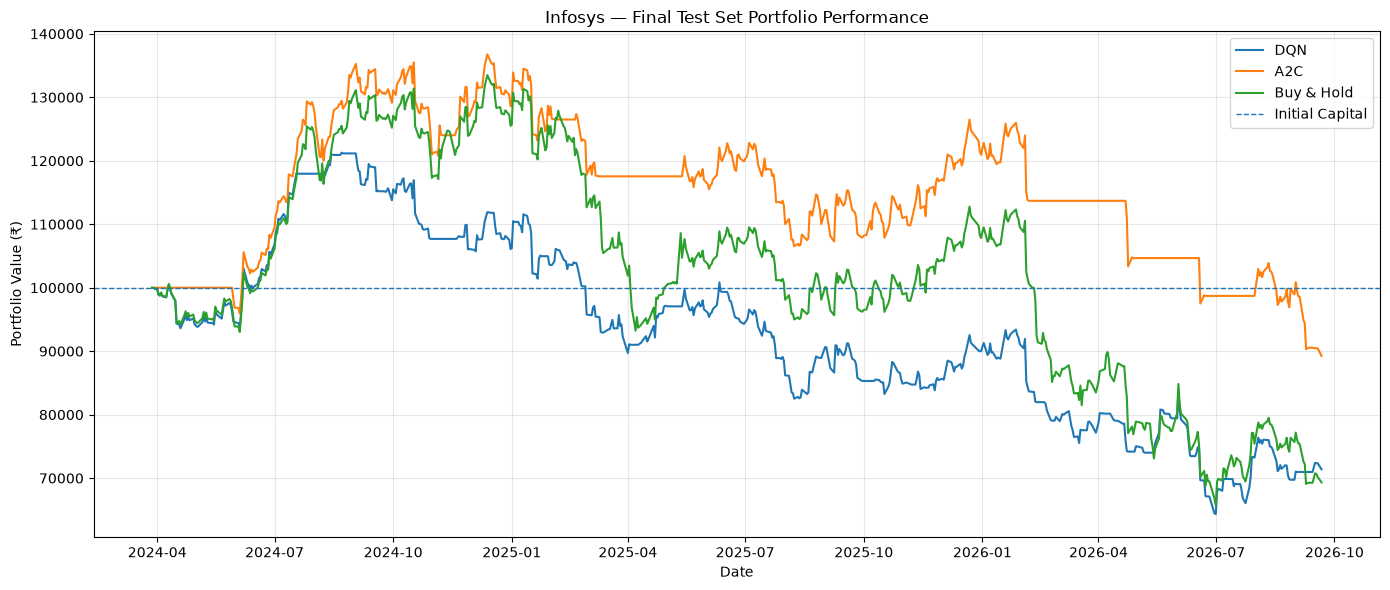

In [50]:
plt.figure(figsize=(14, 6))

plt.plot(
    final_dqn_test["dates"],
    final_dqn_test["portfolio_values"],
    label="DQN",
)

plt.plot(
    final_a2c_test["dates"],
    final_a2c_test["portfolio_values"],
    label="A2C",
)

plt.plot(
    final_buy_hold_test["dates"],
    final_buy_hold_test["portfolio_values"],
    label="Buy & Hold",
)

plt.axhline(
    INITIAL_CAPITAL,
    linestyle="--",
    linewidth=1,
    label="Initial Capital",
)

plt.title(f"{COMPANY} — Final Test Set Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()